# HW3-2: Enhanced DQN Variants — Player Mode

比較三個版本：
- **Naive DQN**（程式 3.8 baseline）
- **Double DQN**
- **Dueling DQN**

環境：GridWorld `player` mode（玩家位置隨機，其他物件固定）

## Step 1：下載環境 & Import

In [1]:
# 下載 GridWorld 環境
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/Gridworld.py
!wget -q https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction/raw/master/Errata/GridBoard.py

import numpy as np
import torch
import torch.nn as nn
import copy
import random
from collections import deque
from matplotlib import pylab as plt
from Gridworld import Gridworld
from IPython.display import clear_output

# 動作對應表
action_set = {0: 'u', 1: 'd', 2: 'l', 3: 'r'}

print('環境載入成功！')

環境載入成功！


## Step 2：共用工具函式

In [2]:
def test_model(model, mode='player', display=False, max_moves=15):
    """
    測試模型，回傳是否獲勝（True/False）
    - model: 要測試的 Q 網路
    - mode: 遊戲模式（player/static/random）
    - display: 是否印出每一步的地圖
    - max_moves: 最多走幾步
    """
    i = 0
    test_game = Gridworld(size=4, mode=mode)
    state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
    state = torch.from_numpy(state_).float()
    if display:
        print('Initial State:')
        print(test_game.display())
    status = 1
    while status == 1:
        qval = model(state)
        qval_ = qval.data.numpy()
        action_ = np.argmax(qval_)
        action = action_set[action_]
        if display:
            print(f'Move #{i}; Taking action: {action}')
        test_game.makeMove(action)
        state_ = test_game.board.render_np().reshape(1,64) + np.random.rand(1,64)/10.0
        state = torch.from_numpy(state_).float()
        if display:
            print(test_game.display())
        reward = test_game.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print(f'Game won! Reward: {reward}')
            else:
                status = 0
                if display:
                    print(f'Game LOST. Reward: {reward}')
        i += 1
        if i > max_moves:
            if display:
                print('Game lost; too many moves.')
            break
    return True if status == 2 else False


def evaluate_model(model, mode='player', n_games=500):
    """評估模型在 n_games 場遊戲中的勝率"""
    wins = sum(test_model(model, mode=mode) for _ in range(n_games))
    win_rate = wins / n_games * 100
    print(f'Games: {n_games} | Wins: {wins} | Win Rate: {win_rate:.1f}%')
    return win_rate


print('工具函式載入完成！')

工具函式載入完成！


---
## Part 1：Naive DQN（Baseline）
直接使用程式 3.8，mode 改為 `player`

In [3]:
# ===== Naive DQN 模型 =====
L1, L2, L3, L4 = 64, 150, 100, 4

naive_model = torch.nn.Sequential(
    torch.nn.Linear(L1, L2),
    torch.nn.ReLU(),
    torch.nn.Linear(L2, L3),
    torch.nn.ReLU(),
    torch.nn.Linear(L3, L4)
)
naive_model2 = copy.deepcopy(naive_model)
naive_model2.load_state_dict(naive_model.state_dict())

naive_optimizer = torch.optim.Adam(naive_model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

# ===== 訓練超參數 =====
epochs    = 5000
gamma     = 0.9
epsilon   = 1.0
mem_size  = 1000
batch_size= 200
max_moves = 50
sync_freq = 500
MODE      = 'player'   # ← HW3-2 使用 player mode

# ===== 訓練迴圈 =====
naive_losses = []
replay = deque(maxlen=mem_size)
j = 0
epsilon = 1.0

for i in range(epochs):
    game = Gridworld(size=4, mode=MODE)
    state1_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
    state1 = torch.from_numpy(state1_).float()
    status = 1
    mov = 0
    while status == 1:
        j += 1
        mov += 1
        qval = naive_model(state1)
        qval_ = qval.data.numpy()
        if random.random() < epsilon:
            action_ = np.random.randint(0,4)
        else:
            action_ = np.argmax(qval_)
        action = action_set[action_]
        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        state2 = torch.from_numpy(state2_).float()
        reward = game.reward()
        done = True if reward != -1 else False
        exp = (state1, action_, reward, state2, done)
        replay.append(exp)
        state1 = state2
        if len(replay) > batch_size:
            minibatch = random.sample(replay, batch_size)
            s1b = torch.cat([s1 for (s1,a,r,s2,d) in minibatch])
            ab  = torch.Tensor([a  for (s1,a,r,s2,d) in minibatch])
            rb  = torch.Tensor([r  for (s1,a,r,s2,d) in minibatch])
            s2b = torch.cat([s2 for (s1,a,r,s2,d) in minibatch])
            db  = torch.Tensor([d  for (s1,a,r,s2,d) in minibatch])
            Q1 = naive_model(s1b)
            with torch.no_grad():
                Q2 = naive_model2(s2b)   # Naive：model2 直接取 max
            Y = rb + gamma * ((1 - db) * torch.max(Q2, dim=1)[0])
            X = Q1.gather(dim=1, index=ab.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            naive_optimizer.zero_grad()
            loss.backward()
            naive_optimizer.step()
            if j % sync_freq == 0:
                naive_model2.load_state_dict(naive_model.state_dict())
            naive_losses.append(loss.item())
        if reward != -1 or mov > max_moves:
            status = 0
            mov = 0
    if epsilon > 0.1:
        epsilon -= (1/epochs)
    if i % 500 == 0:
        print(f'Naive DQN Epoch {i}/{epochs}')
        clear_output(wait=True)

print('Naive DQN 訓練完成！')

Naive DQN 訓練完成！


In [4]:
print('=== Naive DQN 評估 ===')
naive_win_rate = evaluate_model(naive_model, mode='player', n_games=500)

=== Naive DQN 評估 ===
Games: 500 | Wins: 500 | Win Rate: 100.0%


---
## Part 2：Double DQN

**改動說明：**
與 Naive DQN 唯一的差別在計算 TD Target 的方式：
- Naive：用 `model2` 同時選動作＋評估價值 → 高估
- Double：用 `model`（online net）選動作，用 `model2`（target net）評估價值 → 修正高估

In [5]:
# ===== Double DQN 模型（架構與 Naive 完全相同）=====
double_model = torch.nn.Sequential(
    torch.nn.Linear(L1, L2),
    torch.nn.ReLU(),
    torch.nn.Linear(L2, L3),
    torch.nn.ReLU(),
    torch.nn.Linear(L3, L4)
)
double_model2 = copy.deepcopy(double_model)
double_model2.load_state_dict(double_model.state_dict())

double_optimizer = torch.optim.Adam(double_model.parameters(), lr=1e-3)

# ===== 訓練迴圈 =====
double_losses = []
replay = deque(maxlen=mem_size)
j = 0
epsilon = 1.0

for i in range(epochs):
    game = Gridworld(size=4, mode=MODE)
    state1_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
    state1 = torch.from_numpy(state1_).float()
    status = 1
    mov = 0
    while status == 1:
        j += 1
        mov += 1
        qval = double_model(state1)
        qval_ = qval.data.numpy()
        if random.random() < epsilon:
            action_ = np.random.randint(0,4)
        else:
            action_ = np.argmax(qval_)
        action = action_set[action_]
        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        state2 = torch.from_numpy(state2_).float()
        reward = game.reward()
        done = True if reward != -1 else False
        exp = (state1, action_, reward, state2, done)
        replay.append(exp)
        state1 = state2
        if len(replay) > batch_size:
            minibatch = random.sample(replay, batch_size)
            s1b = torch.cat([s1 for (s1,a,r,s2,d) in minibatch])
            ab  = torch.Tensor([a  for (s1,a,r,s2,d) in minibatch])
            rb  = torch.Tensor([r  for (s1,a,r,s2,d) in minibatch])
            s2b = torch.cat([s2 for (s1,a,r,s2,d) in minibatch])
            db  = torch.Tensor([d  for (s1,a,r,s2,d) in minibatch])
            Q1 = double_model(s1b)
            with torch.no_grad():
                # ===== Double DQN 關鍵改動 =====
                Q2_online = double_model(s2b)            # online net 選動作
                best_actions = Q2_online.argmax(dim=1)   # 找最好動作的 index
                Q2_target = double_model2(s2b)           # target net 評估價值
                Q2_val = Q2_target.gather(1, best_actions.unsqueeze(1)).squeeze()
                # ================================
            Y = rb + gamma * ((1 - db) * Q2_val)
            X = Q1.gather(dim=1, index=ab.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            double_optimizer.zero_grad()
            loss.backward()
            double_optimizer.step()
            if j % sync_freq == 0:
                double_model2.load_state_dict(double_model.state_dict())
            double_losses.append(loss.item())
        if reward != -1 or mov > max_moves:
            status = 0
            mov = 0
    if epsilon > 0.1:
        epsilon -= (1/epochs)
    if i % 500 == 0:
        print(f'Double DQN Epoch {i}/{epochs}')
        clear_output(wait=True)

print('Double DQN 訓練完成！')

Double DQN 訓練完成！


In [6]:
print('=== Double DQN 評估 ===')
double_win_rate = evaluate_model(double_model, mode='player', n_games=500)

=== Double DQN 評估 ===
Games: 500 | Wins: 500 | Win Rate: 100.0%


---
## Part 3：Dueling DQN

**改動說明：**
修改網路架構，將 Q(s,a) 拆成兩個部分學習：
- `V(s)`：狀態價值（這個狀態本身有多好，與動作無關）
- `A(s,a)`：動作優勢（這個動作比平均好多少）
- 合併公式：`Q(s,a) = V(s) + A(s,a) - mean(A(s,a))`

In [7]:
# ===== Dueling DQN 網路架構 =====
class DuelingDQN(nn.Module):
    def __init__(self):
        super(DuelingDQN, self).__init__()
        # 共用特徵提取層（backbone）
        self.backbone = nn.Sequential(
            nn.Linear(64, 150),
            nn.ReLU(),
            nn.Linear(150, 100),
            nn.ReLU()
        )
        # Value stream：輸出 1 個值，代表 V(s)
        self.value_stream = nn.Linear(100, 1)
        # Advantage stream：輸出 4 個值，代表每個動作的 A(s,a)
        self.adv_stream = nn.Linear(100, 4)

    def forward(self, x):
        x = self.backbone(x)
        V = self.value_stream(x)          # shape: (batch, 1)
        A = self.adv_stream(x)            # shape: (batch, 4)
        # 減去平均優勢，確保 V 和 A 能被唯一識別
        Q = V + (A - A.mean(dim=1, keepdim=True))
        return Q                           # shape: (batch, 4)


# ===== 建立模型 =====
dueling_model  = DuelingDQN()
dueling_model2 = DuelingDQN()
dueling_model2.load_state_dict(dueling_model.state_dict())

dueling_optimizer = torch.optim.Adam(dueling_model.parameters(), lr=1e-3)

# ===== 訓練迴圈（與 Naive 完全相同，只換了網路）=====
dueling_losses = []
replay = deque(maxlen=mem_size)
j = 0
epsilon = 1.0

for i in range(epochs):
    game = Gridworld(size=4, mode=MODE)
    state1_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
    state1 = torch.from_numpy(state1_).float()
    status = 1
    mov = 0
    while status == 1:
        j += 1
        mov += 1
        qval = dueling_model(state1)
        qval_ = qval.data.numpy()
        if random.random() < epsilon:
            action_ = np.random.randint(0,4)
        else:
            action_ = np.argmax(qval_)
        action = action_set[action_]
        game.makeMove(action)
        state2_ = game.board.render_np().reshape(1,64) + np.random.rand(1,64)/100.0
        state2 = torch.from_numpy(state2_).float()
        reward = game.reward()
        done = True if reward != -1 else False
        exp = (state1, action_, reward, state2, done)
        replay.append(exp)
        state1 = state2
        if len(replay) > batch_size:
            minibatch = random.sample(replay, batch_size)
            s1b = torch.cat([s1 for (s1,a,r,s2,d) in minibatch])
            ab  = torch.Tensor([a  for (s1,a,r,s2,d) in minibatch])
            rb  = torch.Tensor([r  for (s1,a,r,s2,d) in minibatch])
            s2b = torch.cat([s2 for (s1,a,r,s2,d) in minibatch])
            db  = torch.Tensor([d  for (s1,a,r,s2,d) in minibatch])
            Q1 = dueling_model(s1b)
            with torch.no_grad():
                Q2 = dueling_model2(s2b)  # Dueling 架構自動處理 V+A
            Y = rb + gamma * ((1 - db) * torch.max(Q2, dim=1)[0])
            X = Q1.gather(dim=1, index=ab.long().unsqueeze(dim=1)).squeeze()
            loss = loss_fn(X, Y.detach())
            dueling_optimizer.zero_grad()
            loss.backward()
            dueling_optimizer.step()
            if j % sync_freq == 0:
                dueling_model2.load_state_dict(dueling_model.state_dict())
            dueling_losses.append(loss.item())
        if reward != -1 or mov > max_moves:
            status = 0
            mov = 0
    if epsilon > 0.1:
        epsilon -= (1/epochs)
    if i % 500 == 0:
        print(f'Dueling DQN Epoch {i}/{epochs}')
        clear_output(wait=True)

print('Dueling DQN 訓練完成！')

Dueling DQN 訓練完成！


In [8]:
print('=== Dueling DQN 評估 ===')
dueling_win_rate = evaluate_model(dueling_model, mode='player', n_games=500)

=== Dueling DQN 評估 ===
Games: 500 | Wins: 500 | Win Rate: 100.0%


---
## Step 3：三個版本比較圖

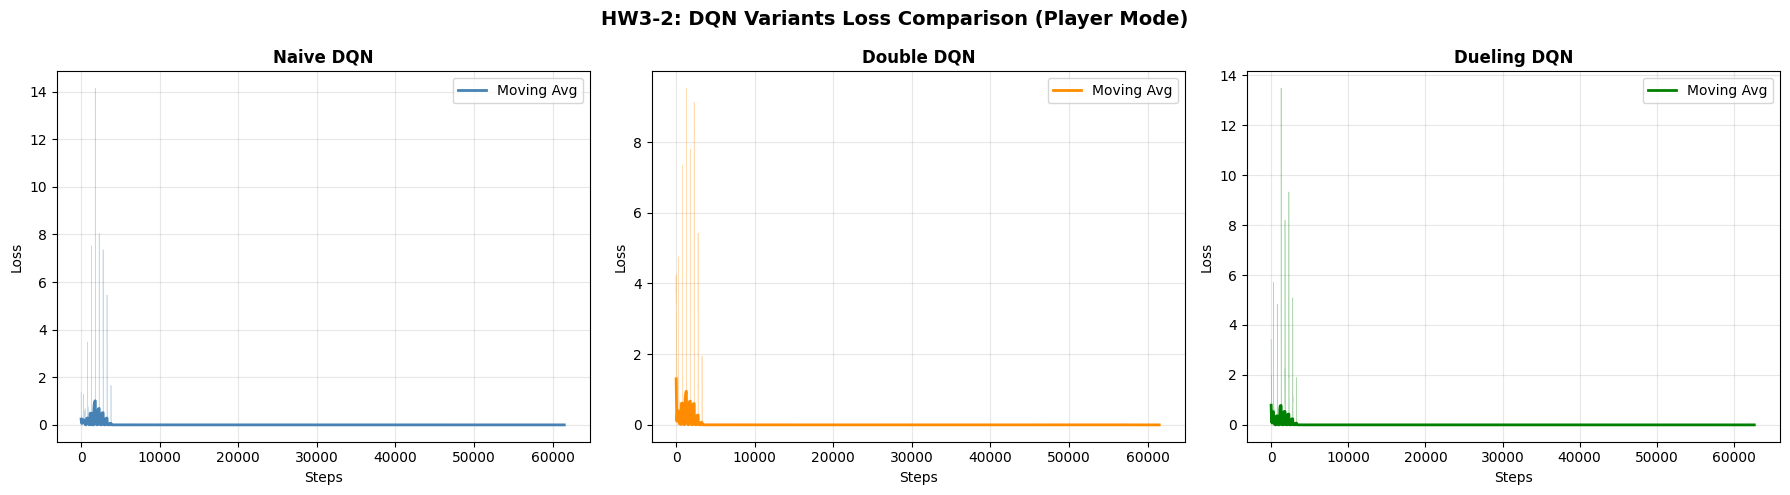

Loss 比較圖已儲存為 loss_comparison.png


In [9]:
# ===== Loss 曲線比較圖 =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('HW3-2: DQN Variants Loss Comparison (Player Mode)', fontsize=14, fontweight='bold')

# 用移動平均讓曲線更好看
def moving_avg(data, window=200):
    return np.convolve(data, np.ones(window)/window, mode='valid')

for ax, losses, title, color in zip(
    axes,
    [naive_losses, double_losses, dueling_losses],
    ['Naive DQN', 'Double DQN', 'Dueling DQN'],
    ['steelblue', 'darkorange', 'green']
):
    ax.plot(losses, alpha=0.3, color=color, linewidth=0.5)
    if len(losses) > 200:
        ax.plot(moving_avg(losses), color=color, linewidth=2, label='Moving Avg')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Steps')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss 比較圖已儲存為 loss_comparison.png')

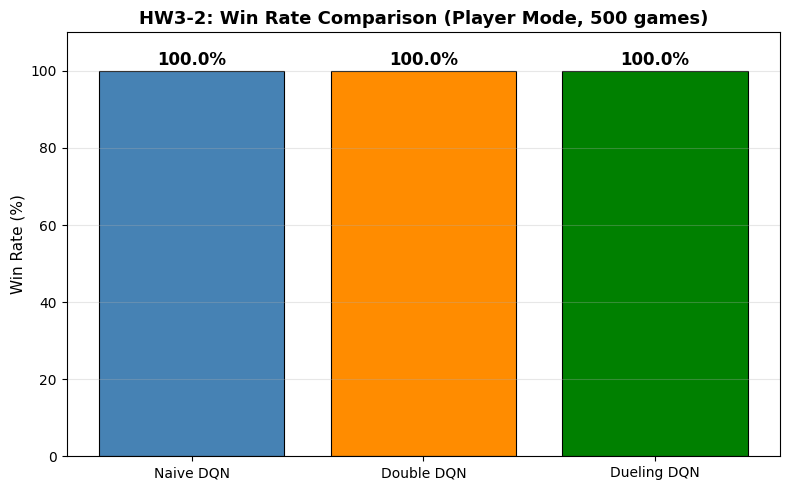

勝率比較圖已儲存為 winrate_comparison.png


In [10]:
# ===== 勝率比較長條圖 =====
models  = ['Naive DQN', 'Double DQN', 'Dueling DQN']
rates   = [naive_win_rate, double_win_rate, dueling_win_rate]
colors  = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rates, color=colors, edgecolor='black', linewidth=0.8)

# 在每個 bar 上標示數字
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('HW3-2: Win Rate Comparison (Player Mode, 500 games)', fontsize=13, fontweight='bold')
plt.ylabel('Win Rate (%)', fontsize=11)
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('winrate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('勝率比較圖已儲存為 winrate_comparison.png')

In [11]:
# ===== 最終結果總結 =====
print('=' * 50)
print('HW3-2 最終結果總結 (Player Mode)')
print('=' * 50)
print(f'Naive DQN  勝率：{naive_win_rate:.1f}%')
print(f'Double DQN 勝率：{double_win_rate:.1f}%  (vs Naive: {double_win_rate - naive_win_rate:+.1f}%)')
print(f'Dueling DQN勝率：{dueling_win_rate:.1f}%  (vs Naive: {dueling_win_rate - naive_win_rate:+.1f}%)')
print('=' * 50)
best = models[rates.index(max(rates))]
print(f'最佳模型：{best}')

HW3-2 最終結果總結 (Player Mode)
Naive DQN  勝率：100.0%
Double DQN 勝率：100.0%  (vs Naive: +0.0%)
Dueling DQN勝率：100.0%  (vs Naive: +0.0%)
最佳模型：Naive DQN
